In [105]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

#Getting csv

In [106]:
data = pd.read_csv('loan defaut_main.csv')
df = pd.DataFrame(data)
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


#EDA

In [107]:
df.shape

(255347, 18)

In [108]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [109]:
#null checking
df.isna().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [110]:
#duplicate checking
df.duplicated().sum()

np.int64(0)

In [111]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


<Axes: xlabel='Default', ylabel='count'>

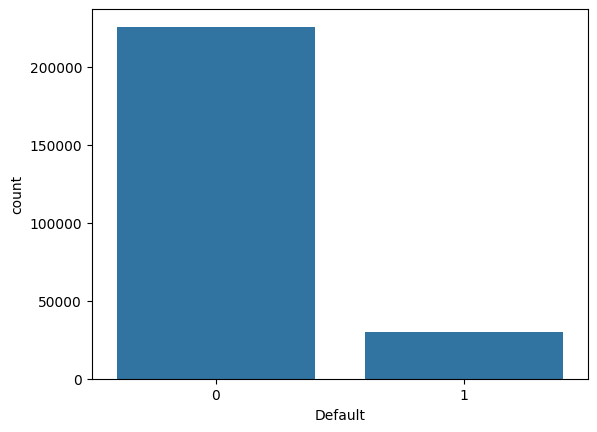

In [112]:
#default(1) vs non_default(0)
sns.countplot(x='Default',data=df)

<Axes: xlabel='Default', ylabel='Income'>

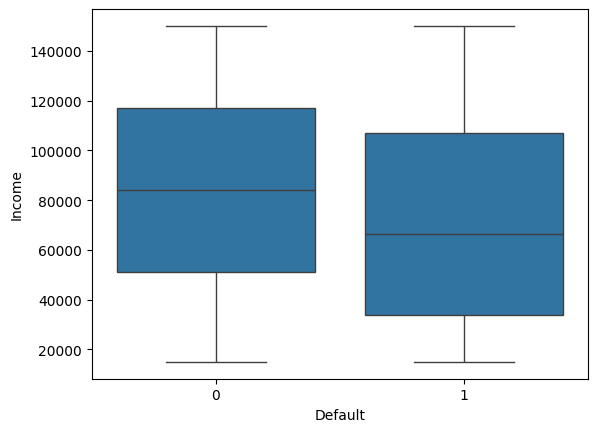

In [113]:
sns.boxplot(
    x='Default',
    y='Income',
    data=df
)

<Axes: >

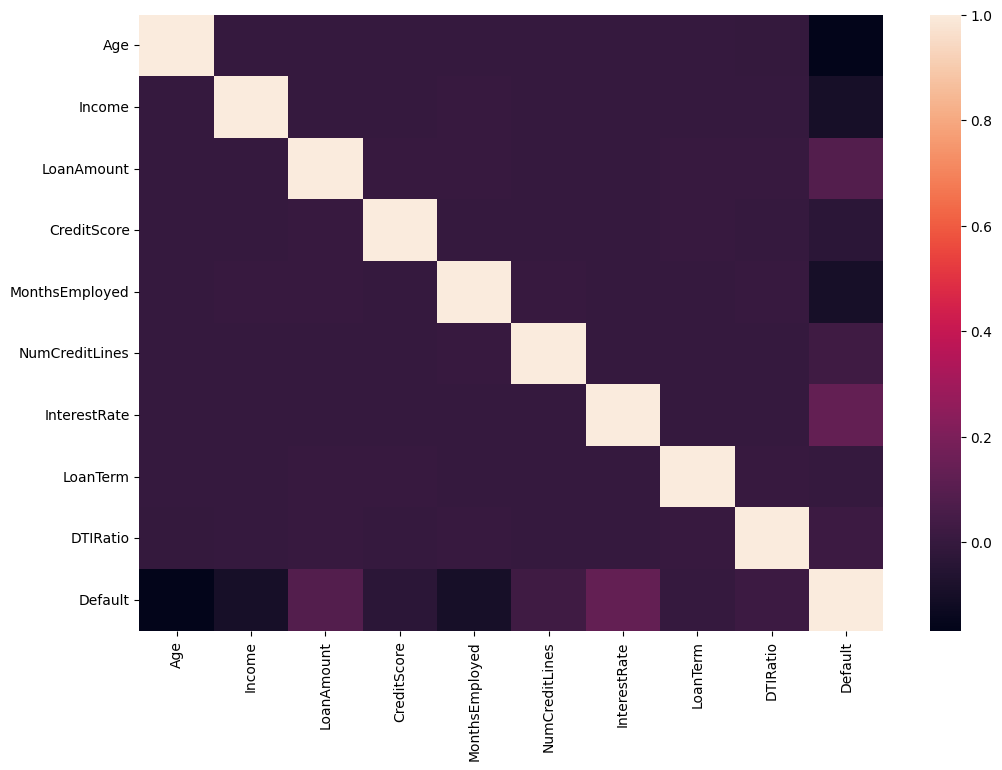

In [114]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True))

In [115]:
df.dtypes

LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

In [116]:
df['Education'].value_counts()

Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64

In [117]:
df['EmploymentType'].value_counts()

EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64

In [118]:
df['HasMortgage'].value_counts()

HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64

In [119]:
df['HasDependents'].value_counts()

HasDependents
Yes    127742
No     127605
Name: count, dtype: int64

In [120]:
df['LoanPurpose'].value_counts()

LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64

In [121]:
df['HasCoSigner'].value_counts()

HasCoSigner
Yes    127701
No     127646
Name: count, dtype: int64

In [122]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64

EDA result : 1.droping loanid column
             2.Changing all yes/no columns into 1/0 ,where 1 for yes and 0 for no (HasCoSigner,HasDependents,HasMortgage)
             3.changing MaritalStatus,LoanPurpose,EmploymentType,Education columns into binary

#Preprocessing

In [123]:
df = df.drop('LoanID',axis=1)

In [124]:
df['HasCoSigner'] = df['HasCoSigner'].apply(lambda x:1 if x == 'Yes' else 0)
df['HasDependents'] = df['HasDependents'].apply(lambda x:1 if x=='Yes' else 0)
df['HasMortgage'] = df['HasMortgage'].apply(lambda x:1 if x =='Yes' else 0)

In [125]:
#one-hot encoding
df = df.join(pd.get_dummies(df.MaritalStatus ,prefix='MaritalStatus', dtype=int)).drop('MaritalStatus',axis=1)
df = df.join(pd.get_dummies(df.LoanPurpose ,prefix='LoanPurpose', dtype=int)).drop('LoanPurpose',axis=1)
df = df.join(pd.get_dummies(df.EmploymentType ,prefix='EmploymentType', dtype=int)).drop('EmploymentType',axis=1)
df = df.join(pd.get_dummies(df.Education ,prefix='Education', dtype=int)).drop('Education',axis=1)

#applying feature engineering to improve model performance

In [126]:
df['LoanToIncomeRatio'] = df['LoanAmount'] / df['Income']
df['DebtExposure'] = df['DTIRatio'] * df['LoanAmount']
df['InterestBurden'] = df['LoanAmount'] * df['InterestRate']

In [127]:
df['InterestToIncome'] = (
    df['LoanAmount'] * df['InterestRate']
) / df['Income']

In [128]:
df['CreditAdjustedLoan'] = (
    df['LoanAmount'] / df['CreditScore']
)

In [129]:
df['IncomePerCreditLine'] = (
    df['Income'] / (df['NumCreditLines'] + 1)
)

In [130]:
df

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,Education_Bachelor's,Education_High School,Education_Master's,Education_PhD,LoanToIncomeRatio,DebtExposure,InterestBurden,InterestToIncome,CreditAdjustedLoan,IncomePerCreditLine
0,56,85994,50587,520,80,4,15.23,36,0.44,1,...,1,0,0,0,0.588262,22258.28,770440.01,8.959230,97.282692,17198.800000
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,0,0,1,0,2.467481,84619.20,598556.40,11.868583,271.703057,25216.000000
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,0,0,1,0,1.534154,40048.28,2734909.96,32.478030,286.447894,21052.000000
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,0,1,0,0,1.412638,10303.77,316728.93,9.987353,60.294751,7928.250000
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,1,0,0,0,0.447179,6671.47,59494.89,2.911136,14.437599,4087.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,19,37979,210682,541,109,4,14.11,12,0.85,0,...,1,0,0,0,5.547329,179079.70,2972723.02,78.272809,389.430684,7595.800000
255343,32,51953,189899,511,14,2,11.55,24,0.21,0,...,0,1,0,0,3.655208,39878.79,2193333.45,42.217648,371.622309,17317.666667
255344,56,84820,208294,597,70,3,5.29,60,0.50,1,...,0,1,0,0,2.455718,104147.00,1101875.26,12.990748,348.901173,21205.000000
255345,42,85109,60575,809,40,1,20.90,48,0.44,1,...,0,1,0,0,0.711734,26653.00,1266017.50,14.875248,74.876391,42554.500000


#Training model

In [131]:
x,y = df.drop('Default',axis=1) , df['Default']

In [132]:
x_train,x_test,y_train,y_test = train_test_split (
    x,y,
    test_size=0.2,
    random_state=42
)

In [133]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [134]:
model = LogisticRegression(max_iter=5000)
model.fit(x_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

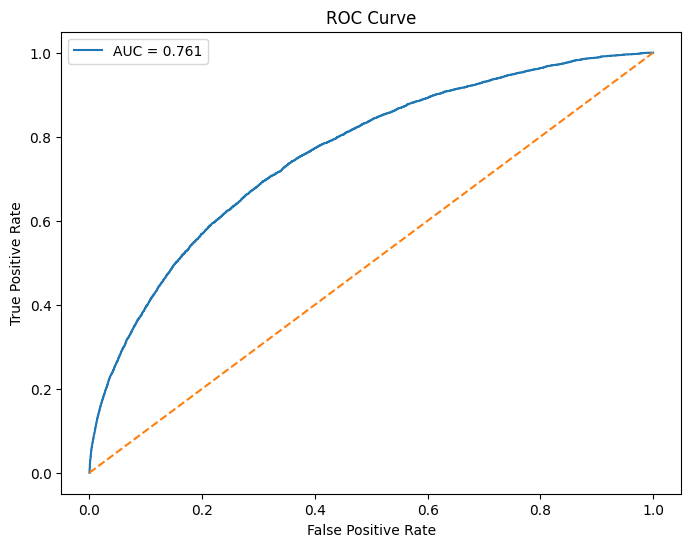

AUC: 0.7607243408141746


In [135]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = model.predict_proba(x_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

print("AUC:", auc)

Top 5 Features Increasing Default Risk

In [146]:
coef_df = pd.DataFrame (
    {
        'Feature' : x.columns,
        'Coefficient' : model.coef_[0] 
    }
)
top_risk = coef_df.sort_values (
    'Coefficient',
    ascending=False
).head(5)

print(top_risk[['Feature','Coefficient']])

                      Feature  Coefficient
28          LoanToIncomeRatio     0.482956
6                InterestRate     0.473621
5              NumCreditLines     0.103300
23  EmploymentType_Unemployed     0.092372
8                    DTIRatio     0.065241


Top 5 Features reducing Default Risk

In [147]:
top_protective = coef_df.sort_values(
    'Coefficient',
    ascending=True
).head(5)

print(top_protective[['Feature','Coefficient']])

                     Feature  Coefficient
0                        Age    -0.599269
4             MonthsEmployed    -0.338770
11               HasCoSigner    -0.142350
10             HasDependents    -0.123299
20  EmploymentType_Full-time    -0.109166
